<a href="https://colab.research.google.com/github/hampanass/FML_Labs/blob/main/Lab6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


MODEL EVALUATION RESULTS

Accuracy  : 0.9649122807017544
Precision : 0.9534883720930233
Recall    : 0.9534883720930233

Confusion Matrix:
[[69  2]
 [ 2 41]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97        71
           1       0.95      0.95      0.95        43

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



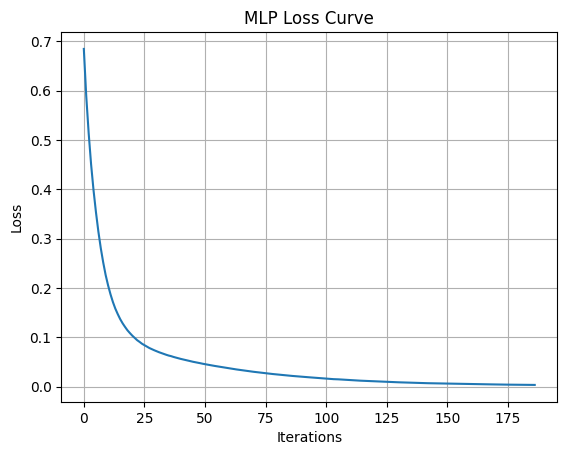

In [1]:
# =========================
# LAB 6: MLP CLASSIFICATION
# Dataset: Breast Cancer Wisconsin (Kaggle)
# =========================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

# -------------------------
# 1. LOAD DATASET
# -------------------------
df = pd.read_csv("data.csv")   # Kaggle file

# -------------------------
# 2. DATA CLEANING
# -------------------------
df.drop(['id', 'Unnamed: 32'], axis=1, inplace=True, errors='ignore')

# Encode target column
le = LabelEncoder()
df['diagnosis'] = le.fit_transform(df['diagnosis'])  # M=1, B=0

# -------------------------
# 3. SPLIT FEATURES & LABEL
# -------------------------
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# -------------------------
# 4. TRAIN-TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------
# 5. FEATURE SCALING
# -------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------
# 6. BUILD MLP MODEL
# -------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42
)

# Train model
mlp.fit(X_train, y_train)

# -------------------------
# 7. PREDICTION
# -------------------------
y_pred = mlp.predict(X_test)

# -------------------------
# 8. EVALUATION METRICS
# -------------------------
print("\n=========================")
print("MODEL EVALUATION RESULTS")
print("=========================\n")

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("Accuracy  :", accuracy)
print("Precision :", precision)
print("Recall    :", recall)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# -------------------------
# 9. LOSS CURVE VISUALIZATION
# -------------------------
plt.plot(mlp.loss_curve_)
plt.title("MLP Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.grid()
plt.show()
